<a href="https://colab.research.google.com/github/raghavkarthikcse2025-coder/daa-lab/blob/main/Exp-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

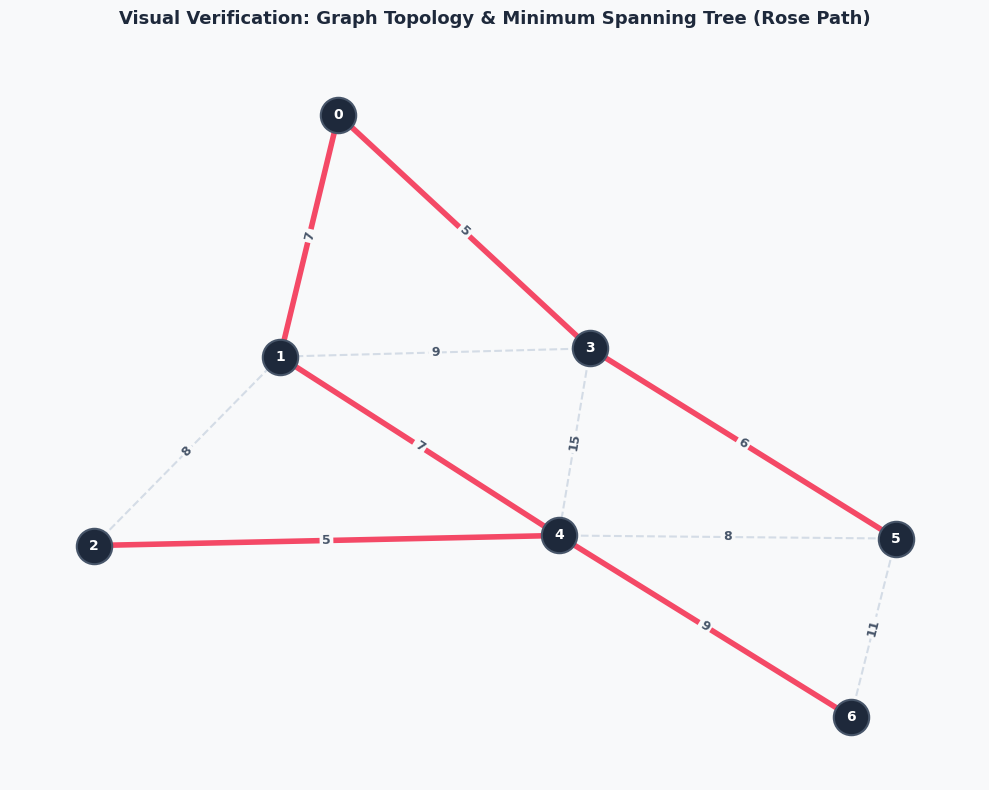

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# --- Simplified Union-Find (Disjoint Set) ---
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # Path compression
        return self.parent[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        self.parent[ry] = rx
        return True

# --- Kruskal's MST Algorithm ---
def kruskal(n, edges):
    edges.sort()  # Sort by weight automatically (w is the first element)
    uf = UnionFind(n)
    mst = []

    for w, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v))
            if len(mst) == n - 1:
                break
    return mst

# --- Graph Data Configuration ---
n = 7
edges = [
    (7, 0, 1), (5, 0, 3), (8, 1, 2), (9, 1, 3),
    (7, 1, 4), (5, 2, 4), (15, 3, 4), (6, 3, 5),
    (8, 4, 5), (9, 4, 6), (11, 5, 6)
]

# Run layout computation
mst_edges = kruskal(n, edges)

# Build NetworkX Graph
G = nx.Graph()
for w, u, v in edges:
    G.add_edge(u, v, weight=w)

# --- Ultra-Polished Visual Styling ---
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
fig.patch.set_facecolor('#F8F9FA')  # Premium light neutral background
ax.set_facecolor('#F8F9FA')

# Normalize edges to guarantee direction-agnostic matching
mst_set = {tuple(sorted((u, v))) for u, v in mst_edges}
baseline_edges = [(u, v) for u, v in G.edges() if tuple(sorted((u, v))) not in mst_set]
mst_edges_to_draw = [(u, v) for u, v in G.edges() if tuple(sorted((u, v))) in mst_set]

# 1. Draw baseline elements (Non-MST Edges)
nx.draw_networkx_edges(
    G, pos, edgelist=baseline_edges,
    width=1.5, edge_color='#CBD5E1', style='dashed', alpha=0.8
)

# 2. Draw Highlighted MST Path (Vibrant Coral/Rose)
nx.draw_networkx_edges(
    G, pos, edgelist=mst_edges_to_draw,
    width=4.0, edge_color='#F43F5E', alpha=0.95
)

# 3. Draw Nodes (Sleek Slate-Navy)
nx.draw_networkx_nodes(
    G, pos, node_color='#1E293B', node_size=650, edgecolors='#475569', linewidths=1.5
)

# 4. Draw Node Labels (Crisp White Text)
nx.draw_networkx_labels(
    G, pos, font_color='#FFFFFF', font_size=10, font_weight='bold'
)

# 5. Draw Edge Weights (Neat Cutout Labels)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,
    font_color='#475569', font_size=9, font_weight='bold',
    bbox=dict(facecolor='#F8F9FA', edgecolor='none', boxstyle='round,pad=0.2')
)

# Formatting adjustments
plt.title("Visual Verification: Graph Topology & Minimum Spanning Tree (Rose Path)",
          fontsize=13, fontweight='bold', pad=20, color='#1E293B')
plt.axis('off')
plt.tight_layout()
plt.show()